# Plan of Action
ek standard interface hai jo har component (Prompt, LLM, Parser, Retriever, Function) ko connect karta hai.

Traditional Chain

chain = prompt | llm | parser

# Runnable Chain POA
Step 1: Input Lo
{"topic": "AI"}

↓

Step 2: Prompt Banao

"Explain AI in simple words"

↓

Step 3: LLM Call Karo

ChatGPT Response

↓

Step 4: Output Parse Karo

String Output

↓

Step 5: Return Result

"AI is a technology..."

# Task-Specific Runnable

Problem: Har task ke liye alag prompt aur logic chahiye.

Agar ek hi chain sab tasks ke liye use karoge to output accurate nahi aayega.

Isliye Task-Specific Runnable banate hain jo ek particular task ko handle kare.



In [ ]:
# Example 1: Summarization Runnable

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

prompt = ChatPromptTemplate.from_template(
    "Summarize the following text:\n{text}"
)

chain = prompt | ChatOpenAI()

chain.invoke({"text": article})



In [ ]:
# Example 2: Translation Runnable
prompt = ChatPromptTemplate.from_template(
    "Translate to Hindi:\n{text}"
)

translator = prompt | ChatOpenAI()

In [ ]:
 #Example 3: Sentiment Analysis Runnable
prompt = ChatPromptTemplate.from_template(
    "Tell whether sentiment is Positive, Negative or Neutral:\n{text}"
)

sentiment_chain = prompt | ChatOpenAI()

# Real Benefit

Ek application me multiple task-specific runnables ho sakte hain:


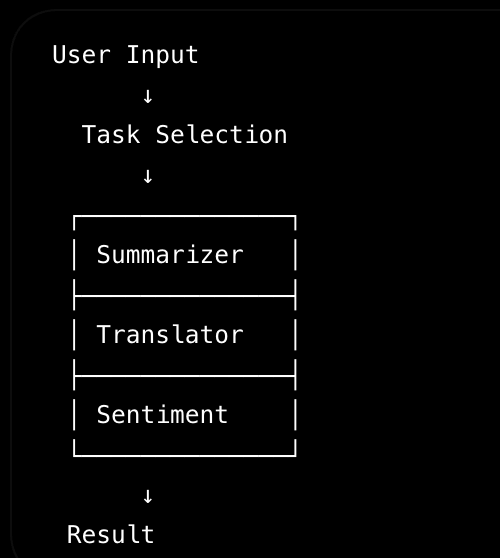

# Task-Specific Runnable ek runnable hota hai jo kisi particular task (summarization, translation, sentiment analysis, etc.) ke liye design kiya jata hai aur input ko task-specific processing karke desired output deta hai.

# Runnable Primitives

Basic building blocks jinse hum complex AI workflows banate hain.



# 1. RunnableSequence

Steps ko one-by-one execute karta hai.

chain = prompt | llm | parser

POA

Input
  ↓
Prompt
  ↓
LLM
  ↓
Parser
  ↓
Output

Example:

Translate text

Summarize article

Generate SQL query

# 2. RunnableParallel

Multiple tasks ko same time run karta hai.

from langchain_core.runnables import RunnableParallel

parallel = RunnableParallel(
    summary=summarizer,
    sentiment=sentiment_chain
)
POA
          Input
            ↓
    ┌───────┴───────┐
    ↓               ↓
Summary       Sentiment
    ↓               ↓
    └───────┬───────┘
            ↓
         Output

Benefit:

Faster execution

Independent tasks together

# 3. RunnableLambda

Custom Python function ko Runnable banata hai.

from langchain_core.runnables import RunnableLambda

def square(x):
    return x * x

r = RunnableLambda(square)

r.invoke(5)

Output:

25

POA

Input
  ↓
Python Function
  ↓
Output

# 4. RunnableBranch

Condition ke basis par different path choose karta hai.

from langchain_core.runnables import RunnableBranch

Example:

Input Text
     ↓
Is English?
 ┌───┴───┐
Yes     No
 ↓        ↓
Translate Skip

POA

Input
  ↓
Condition Check
  ↓
Choose Branch
  ↓
Output

Use Cases:

Language detection

Routing requests

Different prompts
# 5. RunnablePassthrough

Input ko modify kiye bina aage bhejta hai.

from langchain_core.runnables import RunnablePassthrough

POA

Input
  ↓
Passthrough
  ↓
Same Output

Example:

RunnablePassthrough().invoke("Hello")

Output:

Hello

# Runnable Sequence

ek Runnable Primitive hai jo multiple steps ko ek ke baad ek (sequentially) execute karta hai.

# Simple words me:

Step 1 → Step 2 → Step 3 → Final Output

Har step ka output next step ka input ban jata hai.

Problem Kya Thi?

Maan lo tumhe:

Prompt banana hai

LLM call karna hai

Output parse karna hai

Agar manually karoge:

prompt_output = prompt.invoke(data)

llm_output = llm.invoke(prompt_output)

final_output = parser.invoke(llm_output)

Bahut code likhna padega.

Isliye RunnableSequence aaya.

# POA (Plan of Action)
User Input
     ↓
Prompt Template
     ↓
LLM
     ↓
Output Parser
     ↓
Final Result

# Why Use RunnableSequence?
1. Clean Code

Without Sequence:

a = prompt.invoke(data)
b = llm.invoke(a)
c = parser.invoke(b)

With Sequence:

chain = prompt | llm | parser

# 2. Easy to Read
Prompt
   ↓
LLM
   ↓
Parser

Pure workflow ek line me samajh aa jata hai.

 # 3. Reusable

Ek baar chain banao:

chain.invoke(...)
chain.batch(...)
chain.stream(...)

Multiple jagah use kar sakte ho.

# RunnableSequence

LangChain ka primitive hai jo multiple runnables ko sequence (ek ke baad ek) execute karta hai.

Input
  ↓
Runnable 1
  ↓
Runnable 2
  ↓
Runnable 3
  ↓
Output

Har step ka output next step ka input ban jata hai.

# Real-Life Example

Pizza order process:

Order
  ↓
Prepare Pizza
  ↓
Bake Pizza
  ↓
Pack Pizza
  ↓
Deliver Pizza

Yahan har step previous step par depend karta hai.

RunnableSequence bhi exactly aise hi kaam karta hai.

# Code

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_template(
    "Explain {topic}"
)

llm = ChatOpenAI()

parser = StrOutputParser()

chain = prompt | llm | parser

Execution (invoke)

result = chain.invoke({
    "topic": "AI"
})

Behind the scenes

Step 1

Input:

{"topic": "AI"}

↓

Step 2

Prompt:

Explain AI

↓

Step 3

LLM:

AI stands for Artificial Intelligence...

↓

Step 4

Parser:

AI stands for Artificial Intelligence...

↓

Final Output
AI stands for Artificial Intelligence...

In [ ]:
# RunnableParallel

ek Runnable Primitive hai jo multiple runnables ko ek hi input ke saath simultaneously (parallel) run karta hai.

Matlab:

Ek Input
    ↓
 ┌───────┬───────┬───────┐
 ↓       ↓       ↓
Task 1  Task 2  Task 3
 ↓       ↓       ↓
 └───────┴───────┘
         ↓
      Output



# Problem

Maan lo ek review hai:

"This phone is amazing and battery life is great."

Tumhe ek saath:

Summary chahiye

Sentiment chahiye

Keywords chahiye

Agar Sequence use karoge:

Review
  ↓
Summary
  ↓
Sentiment
  ↓
Keywords

Ye slow hoga kyunki har task previous task ke complete hone ka wait karega.



In [ ]:
# Solution: RunnableParallel

Sab tasks ek saath run karo.

                 Review
                    ↓
       ┌────────────┼────────────┐
       ↓            ↓            ↓
   Summary      Sentiment    Keywords
       ↓            ↓            ↓
       └────────────┼────────────┘
                    ↓
              Final Result

# Code


In [ ]:
from langchain_core.runnables import RunnableParallel

parallel_chain = RunnableParallel(
    summary=summarizer_chain,
    sentiment=sentiment_chain,
    keywords=keyword_chain
)

result = parallel_chain.invoke(
    {"text": "This phone is amazing"}
)

print(result)

In [ ]:
# POA (Plan of Action)
Input
  ↓
RunnableParallel
  ↓
 ┌─────────┬─────────┬─────────┐
 ↓         ↓         ↓
Task A   Task B   Task C
 ↓         ↓         ↓
 └─────────┴─────────┘
          ↓
     Combined Output

# Interview Definition

RunnableParallel LangChain ka primitive hai jo ek hi input ko multiple runnables me parallel execute karta hai aur unke outputs ko combine karke return karta hai.

* Memory Trick
Sequence = Train 🚆
(A → B → C)

Parallel = Highway 🛣️
(A, B, C together)

Jab tasks independent hon (summary, sentiment, keywords), tab RunnableParallel use karo. Jab tasks ek dusre par depend karte hon, tab RunnableSequence use karo.

# RunnablePassthrough

RunnablePassthrough input ko bina change kiye aage pass kar deta hai.



In [ ]:
# Code
from langchain_core.runnables import RunnablePassthrough

runnable = RunnablePassthrough()

result = runnable.invoke("Hello")

print(result)

# Why Use It?

Maan lo tumhare paas user ka question hai:

"What is AI?"

Aur tumhe:

Original question bhi chahiye

LLM answer bhi chahiye

Without Passthrough:

Question
   ↓
LLM
   ↓
Answer

Original question lose ho sakta hai.

In [ ]:
from langchain_core.runnables import RunnableParallel, RunnablePassthrough

chain = RunnableParallel(
    question=RunnablePassthrough(),
    answer=llm
)

In [ ]:
# Flow
          Input
            ↓
      "What is AI?"
            ↓
     ┌──────┴──────┐
     ↓             ↓
Passthrough       LLM
     ↓             ↓
Question       Answer
     ↓             ↓
     └──────┬──────┘
            ↓
         Result

In [ ]:
Common Use Case
Keep Original Input + Generate Output
User Question
      ↓
 ┌────┴────┐
 ↓         ↓
Original   LLM
 ↓         ↓
Question   Answer

Baad me dono ko combine kar sakte ho.

In [ ]:
RunnablePassthrough ek runnable primitive hai jo input ko bina kisi modification ke exactly waise hi next step tak forward karta hai.

Input → Passthrough → Same Input

# Memory Trick
Passthrough = Forward as it is

Jaise courier office me package ko bina khole aage bhej diya:

Package
   ↓
Passthrough
   ↓
Same Package

Waise hi:

Input
  ↓
RunnablePassthrough
  ↓
Same Input

# RunnableLambda

Kya hai?

RunnableLambda kisi normal Python function ko Runnable bana deta hai.

Simple words me:

Python Function
       ↓
RunnableLambda
       ↓
LangChain Runnable

In [ ]:
# Problem

Maan lo tumhare paas ek custom function hai:

def square(x):
    return x * x

Ye normal Python function hai.

LangChain chain me directly use nahi kar sakte.

Isliye RunnableLambda use karte hain.

In [ ]:
# Code
from langchain_core.runnables import RunnableLambda

def square(x):
    return x * x

runnable = RunnableLambda(square)

print(runnable.invoke(5))

# RunnableLambda ek LangChain primitive hai jo kisi custom Python function ko Runnable interface me wrap karta hai, taaki use LangChain chains aur pipelines me use kiya ja sake.


# Memory Trick
Lambda = Custom Logic

Yaad Rakho

RunnableSequence     → Ek ke baad ek

RunnableParallel     → Saath-saath

RunnablePassthrough  → Same input forward

RunnableBranch       → If-Else routing

RunnableLambda       → Custom Python function

RunnableLambda ka main purpose:

👉 "Apni custom Python logic ko LangChain workflow ka part banana."

# RunnableBranch

RunnableBranch LangChain ka primitive hai jo condition ke basis par different path (branch) choose karta hai.

# Simple words me:

If Condition True
      ↓
   Chain A

Else
      ↓
   Chain B

Ye programming ke if-else jaisa hi hai.


# Problem

Maan lo user English ya Hindi me question pooch sakta hai.

User Input
    ↓
"What is AI?"

English ho to English chain.

English Chain

Aur

"AI kya hai?"

Hindi ho to Hindi chain.

Hindi Chain

Aise cases me RunnableBranch use hota hai.

In [ ]:
POA (Plan of Action)
Input
  ↓
Condition Check
  ↓
 ┌─────────────┐
 │ True ?      │
 └──────┬──────┘
        │
   Yes  │  No
        │
        ↓
     Chain A
        │
        ↓
     Output

# Language Routing


In [ ]:
branch = RunnableBranch(
    (
        lambda text: "?" in text,
        english_chain
    ),
    hindi_chain
)

  #Flow

User Input
     ↓
Condition Check
     ↓
 ┌──────────────┐
 │ English ?    │
 └──────┬───────┘
        │
   Yes  │  No
        │
        ↓
English Chain
        │
        ↓
 Response

# RunnableBranch ek LangChain primitive hai jo input par conditions evaluate karta hai aur matching condition ke according ek specific runnable/chain execute karta hai.

# LCEL (LangChain Expression Language)

Ye LangChain ka ek declarative syntax hai jisse hum runnables ko easily connect kar sakte hain.

# LCEL = Runnable ko connect karne ki language




LCEL Aane Se Pehle

Pehle manually likhna padta tha:

prompt_output = prompt.invoke(data)

llm_output = llm.invoke(prompt_output)

final_output = parser.invoke(llm_output)

Bahut verbose code tha.

LCEL Ke Baad

chain = prompt | llm | parser

Bas ek line me pura workflow.

# Why LCEL?
Problem

LangChain me bahut components hote hain:

Prompt

LLM

Retriever

Parser

Tools

Inko connect karna difficult tha.

Solution

LCEL ne sabko ek common Runnable interface diya.

Prompt
   ↓
LLM
   ↓
Parser

# LCEL Operators
1. | (Pipe Operator)

Sequence banata hai.

chain = prompt | llm | parser

Flow:

Input
 ↓
Prompt
 ↓
LLM
 ↓
Parser
 ↓
Output

# 2. Dictionary {}

Parallel execution banata hai.

chain = {
    "summary": summarizer,
    "sentiment": sentiment_chain
}

Equivalent to:

RunnableParallel(
    summary=summarizer,
    sentiment=sentiment_chain
)

In [ ]:
# Flow:

           Input
             ↓
      ┌──────┴──────┐
      ↓             ↓
 Summary      Sentiment
      ↓             ↓
      └──────┬──────┘
             ↓
          Output

# LCEL Benefits
1. Readable
prompt | llm | parser

Ek nazar me workflow samajh aata hai.

2. Less Code

Without LCEL:

a = prompt.invoke(data)
b = llm.invoke(a)
c = parser.invoke(b)

With LCEL:

prompt | llm | parser

# LCEL (LangChain Expression Language) LangChain ka declarative syntax hai jo Runnable components ko compose (connect) karne ke liye use hota hai. Ye simple operators jaise | aur {} ka use karke complex AI pipelines ko readable aur concise banata hai.